In [ ]:
import json
from pathlib import Path
import openai
import re
import math
import numpy as np
import torch
from transformers import pipeline
import time
from typing import Optional

from utils import extract_numbers,find_first_empty_index,process_scientific_notation,extract_numeric_answer
openai.api_key  = "openai_api_key"  # Replace with your actual OpenAI API key
xai_api_key = "xai_api_key"  # Replace with your actual XAI API key

from sentence_transformers import SentenceTransformer

model_sentence = SentenceTransformer("all-MiniLM-L6-v2")

/Users/woodywu/anaconda3/envs/XD_LLMD/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


KeyboardInterrupt: 

In [ ]:
# Download APBench_Gamma.json from woodywu/APBench 
filename = 'APBench_Gamma.json'
data = json.loads(Path(filename).read_text())
# Print the tenth problem and the 1st question among the questions
index, order = 10, 1
content   = data[index]['Content']
question_solution_so_on = data[index]['Questions'][order]
print("Content:", content)
print("Question:", question_solution_so_on['Question'])
print("Solution:", question_solution_so_on['Solution'])
print("Answer:", question_solution_so_on['Answer'])
print("Format:", question_solution_so_on['Format'])
print("Source:", question_solution_so_on['Source'])

Content: Calculate the velocity of the satellite at both perigee and apogee.

Given:
- \( R_p = (6,378.14 + 250) \times 1,000 = 6,628,140 \) m
- \( R_a = (6,378.14 + 500) \times 1,000 = 6,878,140 \) m

Equations (4.16) and (4.17),

\[ V_p = \sqrt{\left(\frac{2 \times GM \times R_a} {R_p \times (R_a + R_p)}\right)} \]

\[ V_p = \sqrt{\left(\frac{2 \times 3.986005 \times 10^{14} \times 6,878,140} {6,628,140 \times (6,878,140 + 6,628,140)}\right)} \]

\[ V_p = 7,826 \text{ m/s} \]

\[ V_a = \sqrt{\left(\frac{2 \times GM \times R_p} {R_a \times (R_a + R_p)}\right)} \]

\[ V_a = \sqrt{\left(\frac{2 \times 3.986005 \times 10^{14} \times 6,628,140} {6,878,140 \times (6,878,140 + 6,628,140)}\right)} \]

\[ V_a = 7,542 \text{ m/s} \]
Question: What is the velocity of the satellite at apogee? Please provide the velocity at apogee in meters per second (m/s).
Solution: - Given:
    - Radius at perigee, \( R_p = (6,378.14 + 250) \times 1,000 = 6,628,140 \) m
    - Radius at apogee, \( R_a = (6,378.

In [ ]:
def get_embedding(text):
    return model_sentence.encode(text)

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [ ]:
import anthropic
# Create an instance of the Anthropics API client
client_perturber = anthropic.Anthropic(api_key='anthropic_api_key')  # Replace with your actual API key

In [ ]:
client = openai.OpenAI(
    base_url="https://api.x.ai/v1",
    api_key=xai_api_key,
)

# Creating Perturbed Questions

In [ ]:
def generate_single_perturbation(question: str, content: str, client_perturber, get_embedding, cosine_similarity) -> dict:
    """
    Generate a single semantically equivalent version with different formulation.
    Validates both content and question against originals.
    
    Args:
        question: The original question string
        content: The problem content/context
        client_perturber: Anthropic client instance
        get_embedding: Embedding function
        cosine_similarity: Cosine similarity function
    
    Returns:
        Dictionary with 'content' and 'question' keys, or None if validation fails
    """
    prompt = f"""Given the following problem content and question, generate ONE equivalent version where BOTH the content/problem setup AND the question are reformulated with different wording and structure, while preserving all information and maintaining the same answer.

Original Content:
{content}

Original Question: {question}

Generate exactly 1 reformulated version. Provide BOTH the reformulated content AND the reformulated question.

Format your response EXACTLY as follows:
Content: [Reformulated problem content/setup]
Question: [Reformulated question]
"""

    response = client_perturber.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=1500,
        temperature=1,  # Higher temperature for varied formulations
        messages=[{"role": "user", "content": prompt}]
    )
    
    reply = response.content[0].text.strip()
    
    # Parse content and question from response
    content_text = None
    question_text = None
    
    lines = reply.split('\n')
    for i, line in enumerate(lines):
        line = line.strip()
        
        if line.startswith('Content:'):
            content_text = line[8:].strip()
            # Continue reading until we hit 'Question:'
            j = i + 1
            while j < len(lines) and not lines[j].strip().startswith('Question:'):
                content_text += ' ' + lines[j].strip()
                j += 1
        
        elif line.startswith('Question:'):
            question_text = line[9:].strip()
            # Continue reading until end or next section
            j = i + 1
            while j < len(lines) and lines[j].strip():
                question_text += ' ' + lines[j].strip()
                j += 1
    
    # ===== VALIDATION =====
    # 1. Basic length and presence checks
    if not content_text or not question_text or len(content_text) < 10 or len(question_text) < 5:
        return None
    
    # 2. Check content similarity - should be different but not too different
    content_embedding_original = get_embedding(content)
    content_embedding_perturbed = get_embedding(content_text)
    content_similarity = cosine_similarity(content_embedding_original, content_embedding_perturbed)
    
    # Content should be reformulated: similarity < 0.95 (different wording)
    # But should maintain information: similarity > 0.5 (same core info)
    if content_similarity >= 0.95 or content_similarity <= 0.5:
        return None
    
    # 3. Check question similarity - should be different but not too different
    question_embedding_original = get_embedding(question)
    question_embedding_perturbed = get_embedding(question_text)
    question_similarity = cosine_similarity(question_embedding_original, question_embedding_perturbed)
    
    # Question should be reformulated: similarity < 0.95 (different wording)
    # But should maintain information: similarity > 0.5 (same core info)
    if question_similarity >= 0.95 or question_similarity <= 0.5:
        return None
    
    # All validations passed
    return {
        'content': content_text.strip(),
        'question': question_text.strip(),
        'content_similarity': float(content_similarity),
        'question_similarity': float(question_similarity)
    }


def generate_semantic_perturbations_with_validation(question: str, content: str, client_perturber, get_embedding, cosine_similarity, num_perturbations: int = 5, max_attempts: int = None) -> list:
    """
    Generate N semantically equivalent questions with validation.
    Uses a loop to generate perturbations one at a time with validation,
    continuing until we have the required number of valid perturbations.
    
    Validates:
    - Both content and question are present and non-empty
    - Content is reformulated (0.5 < similarity < 0.95)
    - Question is reformulated (0.5 < similarity < 0.95)
    
    Args:
        question: The original question string
        content: The problem content/context
        client_perturber: Anthropic client instance
        get_embedding: Embedding function
        cosine_similarity: Cosine similarity function
        num_perturbations: Number of valid perturbations to generate (default: 5)
        max_attempts: Maximum attempts per perturbation (default: num_perturbations * 3)
    
    Returns:
        List of N validated dictionaries, each with 'content', 'question', 'content_similarity', 'question_similarity' keys
    """
    if max_attempts is None:
        max_attempts = num_perturbations * 3
    
    perturbations = []
    attempt_count = 0
    max_total_attempts = max_attempts * num_perturbations
    
    while len(perturbations) < num_perturbations and attempt_count < max_total_attempts:
        attempt_count += 1
        print(f"Generating perturbation {len(perturbations) + 1}/{num_perturbations} (attempt {attempt_count})...", end=" ")
        
        perturbation = generate_single_perturbation(question, content, client_perturber, get_embedding, cosine_similarity)
        
        if perturbation is not None:
            # Validation passed
            perturbations.append(perturbation)
            print(f"✓ Valid (content_sim: {perturbation['content_similarity']:.3f}, question_sim: {perturbation['question_similarity']:.3f})")
        else:
            print("✗ Invalid (format, length, or similarity check failed)")
    
    if len(perturbations) < num_perturbations:
        print(f"\nWarning: Only generated {len(perturbations)} valid perturbations out of {num_perturbations} requested")
    else:
        print(f"\n✓ Successfully generated {num_perturbations} valid perturbations")
    
    return perturbations


# ===== GENERATE PERTURBATIONS ONCE FOR THE CURRENT QUESTION =====
num_perturbations = 5

print("Original Content:")
print(f"{content}\n")
print("Original Question:")
print(f"{question_solution_so_on['Question']}\n")

# Generate semantic perturbations with validation loop
print(f"Generating {num_perturbations} semantic perturbations with validation...")
print("Validation criteria:")
print("  - Content similarity: 0.5 < similarity < 0.95 (different wording, same info)")
print("  - Question similarity: 0.5 < similarity < 0.95 (different wording, same info)\n")

perturbed_list = generate_semantic_perturbations_with_validation(
    question_solution_so_on['Question'],
    content,
    client_perturber,
    get_embedding,
    cosine_similarity,
    num_perturbations=num_perturbations
)

# Save perturbations to JSON file for reuse across rounds
perturbations_data = {
    'index': index,
    'order': order,
    'original_content': content,
    'original_question': question_solution_so_on['Question'],
    'original_answer': question_solution_so_on['Answer'],
    'original_format': question_solution_so_on['Format'],
    'original_source': question_solution_so_on['Source'],
    'num_perturbations': len(perturbed_list),
    'perturbations': perturbed_list
}

# with open('perturbations_generated.json', 'w') as f:
    # json.dump(perturbations_data, f, indent=2)
# print("\n✓ Perturbations saved to 'perturbations_generated.json'")


Original Content:
Calculate the velocity of the satellite at both perigee and apogee.

Given:
- \( R_p = (6,378.14 + 250) \times 1,000 = 6,628,140 \) m
- \( R_a = (6,378.14 + 500) \times 1,000 = 6,878,140 \) m

Equations (4.16) and (4.17),

\[ V_p = \sqrt{\left(\frac{2 \times GM \times R_a} {R_p \times (R_a + R_p)}\right)} \]

\[ V_p = \sqrt{\left(\frac{2 \times 3.986005 \times 10^{14} \times 6,878,140} {6,628,140 \times (6,878,140 + 6,628,140)}\right)} \]

\[ V_p = 7,826 \text{ m/s} \]

\[ V_a = \sqrt{\left(\frac{2 \times GM \times R_p} {R_a \times (R_a + R_p)}\right)} \]

\[ V_a = \sqrt{\left(\frac{2 \times 3.986005 \times 10^{14} \times 6,628,140} {6,878,140 \times (6,878,140 + 6,628,140)}\right)} \]

\[ V_a = 7,542 \text{ m/s} \]

Original Question:
What is the velocity of the satellite at apogee? Please provide the velocity at apogee in meters per second (m/s).

Generating 5 semantic perturbations with validation...
Validation criteria:
  - Content similarity: 0.5 < similarity < 0

# Systematic Running on Selected Questions

In [ ]:
def evaluate_frac(frac,
                  content_str,
                  question_str,
                  solution_str,
                  all_correct_QAs,
                  client,
                  get_embedding,
                  cosine_similarity):
    """
    Build the prompt using the first `frac` fraction of `solution_str`,
    call the model, compute the remaining solution, then return the cosine
    similarity between the model's reply and the remainder.
    """
    # how many chars to include
    n = int(len(solution_str) * frac)

    # Build the prompt
    msg = (
        f"{all_correct_QAs} {content_str} {question_str} "
        "Without any extra words, please specify the answer in the final sentence with this form: "
        "'the answer is (answer)'. The answer should either be numeric or symbolic (not words)."
    )
    # append the fraction of the solution
    msg = f"{msg}, {solution_str[:n]}"

    # calling model
    response = client.chat.completions.create(
        model="grok-3-mini-beta", # or "grok-3-mini-fast-beta"
        reasoning_effort="high",
        messages= [{"role": "user","content": msg,}],
        temperature=0,
        )
    reply = response.choices[0].message.content
    print("reply: ", reply)

    # compute remaining solution (after the prefix you gave it)
    remain_sol = solution_str[n:]

    # compute similarity
    sim = cosine_similarity(
        get_embedding(solution_str[:n]+reply),
        get_embedding(solution_str[:n]+remain_sol)
    )

    return sim, reply, remain_sol

def extract_user_answer(reply: str) -> Optional[str]:
    """
    Extracts the substring following 'the answer is' (case-sensitive or not)
    from a model’s reply. Returns the answer (including any LaTeX) or None.
    """
    pattern = r'the answer is\s*(.*)|The answer is\s*(.*)'
    match = re.search(pattern, reply)
    if not match:
        return None
    # whichever group captured the text
    answer = match.group(1) or match.group(2)
    return answer.strip()


In [ ]:
def evaluate_and_update(
    reply: str,
    format_str: str,
    answer_str: str,
    question_str: str,
    content_str: str,
    solution_str: str,
    user_answer_str: str,
    q_idx: int,
    match_results_local: list,
    correct_QAs: list,
    get_embedding,
    cosine_similarity,
    extract_numeric_answer,
    extract_numbers,
    process_scientific_notation,
    openai_client
):
    """
    Evaluate a single model reply and update match_results_local[q_idx] (0 or 1)
    and append to correct_QAs if matched.

    Returns the match_result (0 or 1).
    """
    match_result = 0

    if format_str == 'message':
        # 1) embedding score
        score_embedding = cosine_similarity(
            get_embedding(reply),
            get_embedding(answer_str)
        )
        print(f"[message] embedding similarity: {score_embedding:.3f}")

        # 2) GPT-based score
        gpt_prompt = f"""
Compare the following reply with the expected answer and evaluate their alignment using these criteria:

1. Relevance: Does the reply address the scientific goals and concepts?
2. Completeness: Does it cover the key points?
3. Accuracy: Is the reasoning correct?

Question: {question_str}
Expected Answer: {answer_str}
Reply: {reply}

After evaluating, provide a similarity score between 0 and 10, where:  
    - 10 means the reply perfectly aligns with the expected answer.  
    - 0 means the reply does not align at all.  

Only return the numeric score.
"""
        response = openai_client.chat.completions.create(
            model="gpt-4",
            messages=[{"role": "user", "content": gpt_prompt}],
            temperature=0
        )
        raw = response.choices[0].message.content.strip()
        try:
            score_gpt = float(raw) / 10.0
        except ValueError:
            score_gpt = 0.0
        print(f"[message] GPT score: {score_gpt:.3f}")

        # combine
        score = 0.5 * score_embedding + 0.5 * score_gpt
        print(f"[message] combined score: {score:.3f}")

        if score > 0.6:
            match_results_local[q_idx] = 1
            extra = (
                f"For reference, Q: '{content_str}{question_str}' "
                f"has answer: {reply}"
            )
            correct_QAs.append(extra)
        else:
            match_results_local[q_idx] = 0 

    elif format_str == 'numeric':
        # attempt to parse a numeric from user_answer_str
        print("[numeric] parsing numeric answer")
        power = []
        try:
            if user_answer_str is None:
                user_answer_str = ''
                raise TypeError("user_answer_str cannot be None")
            user_answer_num_str = extract_numeric_answer(user_answer_str)
            user_answer_num = extract_numbers(user_answer_num_str)[0]
        except:
            # check if answer string has power expression
            user_answer_str, power = process_scientific_notation(user_answer_str)
            user_answer_num = None

        # when openai is able to handle the operation
        if not power:
            user_answer_num = user_answer_num
            answer_str_num = extract_numbers(answer_str)[0]
            match_results_local[q_idx] = 0
        # other cases
        else:
            try:
                if power:
                    print("pow")
                    user_answer_pow = extract_numbers(user_answer_str.strip())[2]
                    user_answer_num = extract_numbers(user_answer_str.strip())[0] * 10**user_answer_pow
                    power = extract_numbers(answer_str)[1]
                    answer_str_num = extract_numbers(answer_str)[0] * 10**power

                    print("user_answer_num", user_answer_num)
                    print("answer_str_num", answer_str_num)

                else:
                    print("no pow")
                    print(user_answer_str.strip())
                    user_answer_num = extract_numbers(user_answer_str.strip())[0]
                    answer_str_num = extract_numbers(answer_str)[0]

                    print("user_answer_num", user_answer_num)
                    print("answer_str_num", answer_str_num)

            except:
                user_answer_num = None
                answer_str_num = None
                match_results_local[q_idx] = 0

        if user_answer_num is not None and user_answer_num != 0:
            
            margin = 0.1 + 0.01 * math.log(abs(answer_str_num))
            print("margin: ", margin)
            if answer_str_num == user_answer_num:
                match_results_local[q_idx] = 1
                extra_str = "For reference, a previous question: " + question_str + ". It has answer " + str(user_answer_num)
                correct_QAs.append(extra_str)
                print("Exact Match")
            elif abs(answer_str_num - user_answer_num) / abs(user_answer_num) < abs(margin):
                match_results_local[q_idx] = 1
                extra_str = "For reference, a previous question: " + question_str + ". It has answer " + str(user_answer_num)
                correct_QAs.append(extra_str)
                print("Rough Match")
            else:
                match_results_local[q_idx] = 0
                print("No Match")

    else:
        raise ValueError(f"Unknown format_str: {format_str!r}")

    # update the result list and return
    match_result = match_results_local[q_idx]
    return match_result

## Looping Over idx, q_idx of interest

In [ ]:
pairs = [(6, 2), (14, 0), (19, 6), (22, 2), (22, 3), (24,1), \
    (6,4), (23, 0), (26, 2), (27, 0), (32, 0)]

results_summary = []
# add a time evaluation
start_time = time.time()

# Loop through each question pair
for idx, q_idx in pairs:
    print(f"\n{'='*80}")
    print(f"Running idx={idx}, q_idx={q_idx}")
    print(f"{'='*80}")

    # Extract data
    content_str = data[idx]['Content']
    questions_solutions = data[idx]['Questions']
    question_entry = questions_solutions[q_idx]
    question_str = question_entry['Question']
    solution_str = question_entry['Solution']
    answer_str = question_entry['Answer']
    format_str = question_entry['Format']
    match_results_local = [[] for _ in questions_solutions]
    correct_QAs = []
    all_correct_QAs = " "
    results = []

    # ===== GENERATE 5 PERTURBED VERSIONS =====
    print(f"\nGenerating 5 perturbed versions...")
    perturbed_versions = []
    num_attempts = 0
    max_total_attempts = 50  # Allow up to 50 attempts to get 5 valid perturbations
    
    while len(perturbed_versions) < 5 and num_attempts < max_total_attempts:
        num_attempts += 1
        perturbation = generate_single_perturbation(
            question_str, 
            content_str, 
            client_perturber, 
            get_embedding, 
            cosine_similarity
        )
        
        if perturbation is not None:
            perturbed_versions.append(perturbation)
            print(f"  ✓ Perturbation {len(perturbed_versions)}: content_sim={perturbation['content_similarity']:.3f}, question_sim={perturbation['question_similarity']:.3f}")
        else:
            print(f"  ✗ Attempt {num_attempts}: Failed validation")
    
    if len(perturbed_versions) < 5:
        print(f"\n⚠ Warning: Only generated {len(perturbed_versions)} valid perturbations out of 5")

    # ===== EVALUATE EACH PERTURBED VERSION WITH frac=0 =====
    print(f"\nEvaluating {len(perturbed_versions)} perturbed versions (frac=0, no solution hint)...")
    
    for p_idx, perturbation in enumerate(perturbed_versions):
        perturbed_content = perturbation['content']
        perturbed_question = perturbation['question']
        sim_content = perturbation['content_similarity']
        sim_question= perturbation['question_similarity']
        
        # Evaluate with frac=0 (no solution hint revealed)
        sim, reply, remain_sol = evaluate_frac(
            0.0,
            perturbed_content,
            perturbed_question,
            solution_str,
            all_correct_QAs,
            client,
            get_embedding,
            cosine_similarity
        )

        user_answer_str = extract_user_answer(reply)

        result = evaluate_and_update(
            reply=reply,
            format_str=format_str,
            answer_str=answer_str,
            question_str=perturbed_question,
            content_str=perturbed_content,
            solution_str=solution_str,
            user_answer_str=user_answer_str,
            q_idx=q_idx,
            match_results_local=match_results_local,
            correct_QAs=correct_QAs,
            get_embedding=get_embedding,
            cosine_similarity=cosine_similarity,
            extract_numeric_answer=extract_numeric_answer,
            extract_numbers=extract_numbers,
            process_scientific_notation=process_scientific_notation,
            openai_client=openai
        )
        
        results.append((sim_content, sim_question, sim, result))

    # Extract sim_content, sim_question, sim_solution, and result
    sims_content = np.array([sim_content for sim_content, _, _, _ in results])
    sims_question = np.array([sim_question for _, sim_question, _, _ in results])
    sims_solution = np.array([sim for _, _, sim, _ in results])
    binary_results = np.array([result for _, _, _, result in results])
    mean_result = binary_results.mean()

    # Calculate FLI-R as 
    FLI_R = sims_solution / np.sqrt(sims_content * sims_question)
    
    # Store in summary
    results_summary.append({
        "idx": idx,
        "q_idx": q_idx,
        "Num_perturbed_generated": len(perturbed_versions),
        "Sims_content": sims_content.tolist(),
        "Sims_question": sims_question.tolist(),
        "Sims_solution": sims_solution.tolist(),
        "Binary_Results": binary_results.tolist(),
        "FLI_R": FLI_R.tolist(),
        "mean_result": mean_result,
        "mean_FLI_R": FLI_R.mean()
    })
    # add end time
    end_time = time.time()
    print(f"Time taken: {end_time - start_time:.2f} seconds")

    # show FLI-R and binary results for this question
    print(f"\n(idx={idx}, q_idx={q_idx})")
    print(f"FLI_R: {FLI_R}")
    print(f"Mean FLI_R: {FLI_R.mean()}")
    print(f"Binary_Results: {binary_results}")
    print(f"Mean Result: {mean_result:.3f}")

# show result summary
for item in results_summary:
    print(f"\n(idx={item['idx']}, q_idx={item['q_idx']})")
    print(f"Mean_FLI_R: {item['mean_FLI_R']:.3f}")
    print(f"Mean Result: {item['mean_result']:.3f}")



Running idx=6, q_idx=2

Generating 5 perturbed versions...
  ✓ Perturbation 1: content_sim=0.808, question_sim=0.733
  ✓ Perturbation 2: content_sim=0.825, question_sim=0.757
  ✓ Perturbation 3: content_sim=0.810, question_sim=0.656
  ✓ Perturbation 4: content_sim=0.841, question_sim=0.677
  ✓ Perturbation 5: content_sim=0.829, question_sim=0.750

Evaluating 5 perturbed versions (frac=0, no solution hint)...
reply:  The incoming hyperbolic excess velocity is assumed to be 5.642 km/s based on a Hohmann transfer from Earth to Jupiter. The velocity reduction of 542 m/s is applied at the periapsis, assumed to be at Jupiter's equatorial radius of 71,500 km. The velocity at periapsis before reduction is 59.80 km/s, and after reduction, it is 59.258 km/s. The specific energy is calculated as -16.31 km²/s², leading to a semimajor axis of 3,883,000 km or 0.02595 AU.

the answer is 3883000, 0.02595
[numeric] parsing numeric answer
margin:  0.229348909777664
No Match
reply:  The velocity reducti

In [ ]:
results_summary

[{'idx': 6,
  'q_idx': 2,
  'Num_perturbed_generated': 5,
  'Sims_content': [0.8076337575912476,
   0.8247009515762329,
   0.8095754981040955,
   0.8407575488090515,
   0.8291512131690979],
  'Sims_question': [0.7333487272262573,
   0.7570265531539917,
   0.6564022898674011,
   0.6772778034210205,
   0.7498033046722412],
  'Sims_solution': [0.6212994456291199,
   0.6585662364959717,
   0.5866960883140564,
   0.7295646667480469,
   0.6948780417442322],
  'Binary_Results': [0, 0, 0, 0, 0],
  'FLI_R': [0.8073065259021793,
   0.8334809098896937,
   0.8048213174010671,
   0.9668185705725112,
   0.8812883777445281],
  'mean_result': 0.0,
  'mean_FLI_R': 0.8587431403019957},
 {'idx': 14,
  'q_idx': 0,
  'Num_perturbed_generated': 5,
  'Sims_content': [0.6769018769264221,
   0.6911736130714417,
   0.5970562696456909,
   0.8143641948699951,
   0.7555950880050659],
  'Sims_question': [0.8200229406356812,
   0.8836256265640259,
   0.7685588002204895,
   0.7936452031135559,
   0.8109655976295471],

In [ ]:
# dump my results_summary into a pickle file
import pickle
with open('FSI_R_results_summary.pkl', 'wb') as f:
    pickle.dump(results_summary, f)

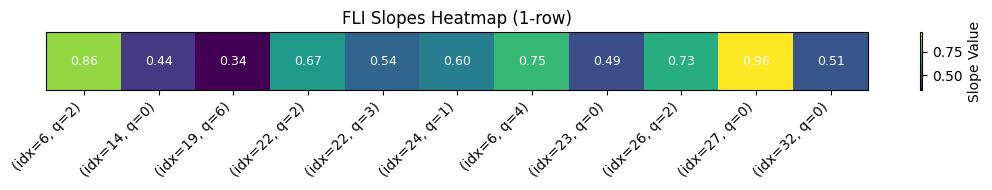

In [ ]:
# single heatmap
import matplotlib.pyplot as plt

# Extract slopes and labels
FLI_R_mean = [float(entry['mean_FLI_R']) for entry in results_summary]
labels = [f"(idx={entry['idx']}, q={entry['q_idx']})" for entry in results_summary]

# Reshape into 1-row heatmap
FLI_R_mean_array = np.array(FLI_R_mean).reshape(1, -1)
# Plot
plt.figure(figsize=(len(FLI_R_mean), 2))
plt.imshow(FLI_R_mean_array, cmap="viridis", aspect="auto")

# Annotate values on heatmap
for i, val in enumerate(FLI_R_mean):
    plt.text(i, 0, f"{val:.2f}", ha='center', va='center', color='white', fontsize=9)

# Axis setup
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha='right')
plt.yticks([])
plt.title("FLI Slopes Heatmap (1-row)")
plt.colorbar(label="Slope Value")
plt.tight_layout()
plt.show()
